# Graph Feature Integration for Rumor Detection

This notebook integrates Knowledge Graph-derived features into the baseline rumor detection model to improve recall.

## Objectives
1. Extract graph features from the PHEME knowledge graph
2. Integrate graph features into the baseline model
3. Run ablation study comparing different feature sets
4. Analyze recall improvement and false negative reduction

## Constraints (DO NOT BREAK)
- NEVER modify `data/processed/pheme_features.csv` or `data/processed/pheme_kg.ttl`
- ALWAYS use `RANDOM_STATE=42` for train/test split
- ALWAYS use stratified 80/20 split
- NEVER fit TF-IDF on full dataset (data leakage)
- Always compare against frozen baseline

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
import sys
sys.path.append('..')

# Constants - DO NOT MODIFY
RANDOM_STATE = 42
TEST_SIZE = 0.2

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Base Dataset

In [2]:
# Load the frozen feature dataset
df = pd.read_csv('../data/processed/pheme_features.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts(normalize=True).map('{:.2%}'.format))
print(f"\nTotal posts: {len(df):,}")
print(f"Non-rumor: {(df['label'] == 0).sum():,} ({df['label'].mean():.1%})")
print(f"Rumor: {(df['label'] == 1).sum():,} ({1 - df['label'].mean():.1%})")

Dataset shape: (102440, 17)

Columns: ['post_id', 'user_id', 'text', 'time', 'event_id', 'reply_to', 'thread_id', 'label', 'depth', 'children_count', 'time_since_source', 'is_source', 'thread_size', 'thread_duration_hours', 'first_reply_time_seconds', 'reply_speed_per_hour', 'max_depth']

Label distribution:
label
0    69.51%
1    30.49%
Name: proportion, dtype: object

Total posts: 102,440
Non-rumor: 71,210 (30.5%)
Rumor: 31,230 (69.5%)


## 2. Extract Graph Features

In [3]:
from utils.graph_features import (
    extract_all_graph_features,
    get_graph_feature_columns,
    get_feature_sets
)

# Extract all graph features
print("Extracting graph features from knowledge graph...")
df_enriched = extract_all_graph_features(df, kg_path='../data/processed/pheme_kg.ttl')

print(f"\nEnriched dataset shape: {df_enriched.shape}")
print(f"Added {len(get_graph_feature_columns())} graph features")
print(f"\nGraph feature columns:")
for col in get_graph_feature_columns():
    print(f"  - {col}")

2026-04-04 04:56:14,695 - INFO - Starting complete graph feature extraction pipeline...


Extracting graph features from knowledge graph...


2026-04-04 04:56:14,721 - INFO - Processing 102440 unique posts


2026-04-04 04:56:14,722 - INFO - Building reply graph from ../data/processed/pheme_kg.ttl


2026-04-04 04:57:14,232 - INFO - Loaded KG with 1065885 triples


...

2026-04-04 04:57:20,011 - INFO - Computed source authority features for 1434577 posts


2026-04-04 04:57:20,028 - INFO - Merging all graph features...


2026-04-04 04:57:20,616 - INFO - Graph feature extraction complete. Added 14 new features.


2026-04-04 04:57:20,616 - INFO - Final dataframe shape: (1434577, 31)



Enriched dataset shape: (1434577, 31)
Added 14 graph features

Graph feature columns:
  - node_in_degree
  - node_out_degree
  - pagerank_score
  - betweenness_centrality
  - closeness_centrality
  - user_prior_rumor_ratio
  - user_post_count
  - user_thread_count
  - user_avg_depth
  - subtree_reply_count
  - sibling_count
  - position_in_thread
  - source_user_credibility
  - source_network_size


In [4]:
# Display statistics of graph features
graph_cols = get_graph_feature_columns()
print("Graph Feature Statistics:")
print("=" * 60)
display(df_enriched[graph_cols].describe().round(4))

Graph Feature Statistics:


,node_in_degree,node_out_degree,pagerank_score,betweenness_centrality,closeness_centrality,user_prior_rumor_ratio,user_post_count,user_thread_count,user_avg_depth,subtree_reply_count,sibling_count,position_in_thread,source_user_credibility,source_network_size
count,1434577.0,1434577.0,1434577.0,1434577.0,1434577.0,1.434577e+06,1.434577e+06,1.434577e+06,1.434577e+06,1434577.0,1434577.0,1.434577e+06,1.434577e+06,1.434577e+06
mean,0.0,0.0,0.0,0.0,0.0,2.560000e-01,1.693950e+01,2.722600e+00,1.152800e+00,0.0,0.0,5.053590e+01,7.439000e-01,1.782420e+01
std,0.0,0.0,0.0,0.0,0.0,3.977000e-01,2.737860e+01,6.726300e+00,9.378000e-01,0.0,0.0,6.180320e+01,3.935000e-01,2.810730e+01
min,0.0,0.0,0.0,0.0,0.0,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.0,0.0,1.000000e+00,0.000000e+00,1.000000e+00
25%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,2.000000e+00,1.000000e+00,5.000000e-01,0.0,0.0,1.100000e+01,5.000000e-01,2.000000e+00
50%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00,0.0,0.0,2.500000e+01,1.000000e+00,7.000000e+00
75%,0.0,0.0,0.0,0.0,0.0,5.000000e-01,2.000000e+01,2.000000e+00,1.636400e+00,0.0,0.0,6.600000e+01,1.000000e+00,2.100000e+01
max,0.0,0.0,0.0,0.0,0.0,1.000000e+00,1.660000e+02,1.040000e+02,1.200000e+01,0.0,0.0,3.460000e+02,1.000000e+00,1.660000e+02


## 3. Baseline Model (Reproduction)

First, we reproduce the baseline model exactly as specified in the frozen pipeline to ensure our comparison is valid.

In [5]:
# Reproduce baseline model exactly
# Features: TF-IDF (5000) + 4 propagation features

# Create train/test split (frozen)
y = df['label']
indices = np.arange(len(df))

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    indices, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {len(X_train_idx):,} samples")
print(f"Test set: {len(X_test_idx):,} samples")
print(f"Train rumor ratio: {y_train.mean():.3f}")
print(f"Test rumor ratio: {y_test.mean():.3f}")

Train set: 81,952 samples
Test set: 20,488 samples
Train rumor ratio: 0.305
Test rumor ratio: 0.305


In [6]:
# Extract TF-IDF features (fit on train only!)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit ONLY on training text
X_train_tfidf = tfidf_vectorizer.fit_transform(df.iloc[X_train_idx]['text'])
X_test_tfidf = tfidf_vectorizer.transform(df.iloc[X_test_idx]['text'])

print(f"TF-IDF features: {X_train_tfidf.shape[1]}")

TF-IDF features: 5000


In [7]:
# Extract propagation features (same as baseline)
# Note: is_reply is derived from depth (depth > 0 means it's a reply)
# The features CSV has is_source, but baseline uses is_reply = 1 - is_source
df['is_reply'] = (df['depth'] > 0).astype(int)
propagation_cols = ['is_reply', 'thread_size', 'children_count', 'depth']

X_train_propagation = df.iloc[X_train_idx][propagation_cols].values
X_test_propagation = df.iloc[X_test_idx][propagation_cols].values

# Scale propagation features
scaler = StandardScaler()
X_train_propagation_scaled = scaler.fit_transform(X_train_propagation)
X_test_propagation_scaled = scaler.transform(X_test_propagation)

print(f"Propagation features: {X_train_propagation.shape[1]}")

Propagation features: 4


In [8]:
# Combine TF-IDF and propagation features
from scipy.sparse import hstack

X_train_baseline = hstack([X_train_tfidf, X_train_propagation_scaled])
X_test_baseline = hstack([X_test_tfidf, X_test_propagation_scaled])

print(f"Baseline feature dimension: {X_train_baseline.shape[1]}")

Baseline feature dimension: 5004


In [9]:
# Train baseline model
baseline_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
baseline_model.fit(X_train_baseline, y_train)

# Predict
y_pred_baseline = baseline_model.predict(X_test_baseline)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_baseline)[:, 1]

# Evaluate
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, pos_label=1),
    'Recall': recall_score(y_test, y_pred_baseline, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_baseline, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_baseline),
    'MCC': matthews_corrcoef(y_test, y_pred_baseline),
}

print("=" * 60)
print("BASELINE MODEL RESULTS (TF-IDF + Propagation)")
print("=" * 60)
for metric, value in baseline_metrics.items():
    print(f"{metric:12s}: {value:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Non-Rumor', 'Rumor']))

BASELINE MODEL RESULTS (TF-IDF + Propagation)
Accuracy    : 0.8065
Precision   : 0.6545
Recall      : 0.7735
F1-Score    : 0.7090
ROC-AUC     : 0.8847
MCC         : 0.5700

Classification Report:
              precision    recall  f1-score   support

   Non-Rumor       0.89      0.82      0.86     14242
       Rumor       0.65      0.77      0.71      6246

    accuracy                           0.81     20488
   macro avg       0.77      0.80      0.78     20488
weighted avg       0.82      0.81      0.81     20488



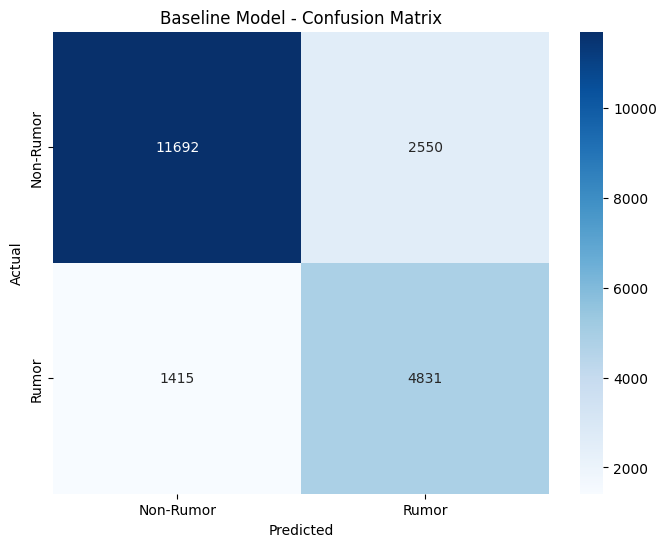

False Negatives (missed rumors): 1415
True Positives (correct rumors): 4831


In [10]:
# Visualize baseline confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Rumor', 'Rumor'],
            yticklabels=['Non-Rumor', 'Rumor'])
plt.title('Baseline Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"False Negatives (missed rumors): {cm_baseline[1, 0]}")
print(f"True Positives (correct rumors): {cm_baseline[1, 1]}")

## 4. Experiment 1: Baseline + Node Centrality Features

In [11]:
# Define feature sets for ablation study
feature_sets = get_feature_sets()

# Experiment 1: Add node centrality only
node_centrality_cols = feature_sets['node_centrality']
print(f"Node centrality features: {node_centrality_cols}")

# Scale graph features
graph_scaler = StandardScaler()
X_train_graph_cent = graph_scaler.fit_transform(df_enriched.iloc[X_train_idx][node_centrality_cols])
X_test_graph_cent = graph_scaler.transform(df_enriched.iloc[X_test_idx][node_centrality_cols])

# Combine with baseline
X_train_exp1 = hstack([X_train_baseline, X_train_graph_cent])
X_test_exp1 = hstack([X_test_baseline, X_test_graph_cent])

print(f"Experiment 1 feature dimension: {X_train_exp1.shape[1]}")

Node centrality features: ['node_in_degree', 'node_out_degree', 'pagerank_score']
Experiment 1 feature dimension: 5007


In [12]:
# Train and evaluate Experiment 1
model_exp1 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
model_exp1.fit(X_train_exp1, y_train)

y_pred_exp1 = model_exp1.predict(X_test_exp1)
y_pred_proba_exp1 = model_exp1.predict_proba(X_test_exp1)[:, 1]

exp1_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_exp1),
    'Precision': precision_score(y_test, y_pred_exp1, pos_label=1),
    'Recall': recall_score(y_test, y_pred_exp1, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_exp1, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_exp1),
    'MCC': matthews_corrcoef(y_test, y_pred_exp1),
}

print("=" * 60)
print("EXPERIMENT 1: Baseline + Node Centrality")
print("=" * 60)
for metric, value in exp1_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

EXPERIMENT 1: Baseline + Node Centrality
Accuracy    : 0.8073 (↑ 0.0008)
Precision   : 0.6558 (↑ 0.0013)
Recall      : 0.7743 (↑ 0.0008)
F1-Score    : 0.7101 (↑ 0.0011)
ROC-AUC     : 0.8849 (↑ 0.0001)
MCC         : 0.5717 (↑ 0.0017)


## 5. Experiment 2: Baseline + User Reputation Features

In [13]:
# Experiment 2: Add user reputation only
user_rep_cols = feature_sets['user_reputation']
print(f"User reputation features: {user_rep_cols}")

# Scale graph features
graph_scaler2 = StandardScaler()
X_train_graph_user = graph_scaler2.fit_transform(df_enriched.iloc[X_train_idx][user_rep_cols])
X_test_graph_user = graph_scaler2.transform(df_enriched.iloc[X_test_idx][user_rep_cols])

# Combine with baseline
X_train_exp2 = hstack([X_train_baseline, X_train_graph_user])
X_test_exp2 = hstack([X_test_baseline, X_test_graph_user])

print(f"Experiment 2 feature dimension: {X_train_exp2.shape[1]}")

User reputation features: ['user_prior_rumor_ratio', 'user_post_count']
Experiment 2 feature dimension: 5006


In [14]:
# Train and evaluate Experiment 2
model_exp2 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
model_exp2.fit(X_train_exp2, y_train)

y_pred_exp2 = model_exp2.predict(X_test_exp2)
y_pred_proba_exp2 = model_exp2.predict_proba(X_test_exp2)[:, 1]

exp2_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_exp2),
    'Precision': precision_score(y_test, y_pred_exp2, pos_label=1),
    'Recall': recall_score(y_test, y_pred_exp2, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_exp2, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_exp2),
    'MCC': matthews_corrcoef(y_test, y_pred_exp2),
}

print("=" * 60)
print("EXPERIMENT 2: Baseline + User Reputation")
print("=" * 60)
for metric, value in exp2_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

EXPERIMENT 2: Baseline + User Reputation
Accuracy    : 0.8075 (↑ 0.0010)
Precision   : 0.6556 (↑ 0.0011)
Recall      : 0.7763 (↑ 0.0029)
F1-Score    : 0.7109 (↑ 0.0019)
ROC-AUC     : 0.8849 (↑ 0.0002)
MCC         : 0.5727 (↑ 0.0027)


## 6. Experiment 3: Baseline + All Graph Features

In [15]:
# Experiment 3: Add all graph features
all_graph_cols = feature_sets['all_graph_features']
print(f"All graph features ({len(all_graph_cols)}): {all_graph_cols}")

# Scale graph features
graph_scaler3 = StandardScaler()
X_train_graph_all = graph_scaler3.fit_transform(df_enriched.iloc[X_train_idx][all_graph_cols])
X_test_graph_all = graph_scaler3.transform(df_enriched.iloc[X_test_idx][all_graph_cols])

# Combine with baseline
X_train_exp3 = hstack([X_train_baseline, X_train_graph_all])
X_test_exp3 = hstack([X_test_baseline, X_test_graph_all])

print(f"Experiment 3 feature dimension: {X_train_exp3.shape[1]}")

All graph features (14): ['node_in_degree', 'node_out_degree', 'pagerank_score', 'betweenness_centrality', 'closeness_centrality', 'user_prior_rumor_ratio', 'user_post_count', 'user_thread_count', 'user_avg_depth', 'subtree_reply_count', 'sibling_count', 'position_in_thread', 'source_user_credibility', 'source_network_size']
Experiment 3 feature dimension: 5018


In [16]:
# Train and evaluate Experiment 3
model_exp3 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
model_exp3.fit(X_train_exp3, y_train)

y_pred_exp3 = model_exp3.predict(X_test_exp3)
y_pred_proba_exp3 = model_exp3.predict_proba(X_test_exp3)[:, 1]

exp3_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_exp3),
    'Precision': precision_score(y_test, y_pred_exp3, pos_label=1),
    'Recall': recall_score(y_test, y_pred_exp3, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_exp3, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_exp3),
    'MCC': matthews_corrcoef(y_test, y_pred_exp3),
}

print("=" * 60)
print("EXPERIMENT 3: Baseline + All Graph Features")
print("=" * 60)
for metric, value in exp3_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

EXPERIMENT 3: Baseline + All Graph Features
Accuracy    : 0.8092 (↑ 0.0027)
Precision   : 0.6584 (↑ 0.0039)
Recall      : 0.7775 (↑ 0.0040)
F1-Score    : 0.7130 (↑ 0.0040)
ROC-AUC     : 0.8858 (↑ 0.0010)
MCC         : 0.5760 (↑ 0.0060)


## 7. Experiment 4: Graph Features Only (No TF-IDF)

In [17]:
# Experiment 4: Graph features only (no TF-IDF)
# This tests how much signal is in graph features + propagation (no TF-IDF)

# Use only propagation + graph features (no TF-IDF)
from scipy.sparse import csr_matrix

X_train_prop_scaled_exp4 = scaler.transform(df.iloc[X_train_idx][propagation_cols].values)
X_test_prop_scaled_exp4 = scaler.transform(df.iloc[X_test_idx][propagation_cols].values)

# Convert to sparse for hstack compatibility
X_train_prop_sparse = csr_matrix(X_train_prop_scaled_exp4)
X_test_prop_sparse = csr_matrix(X_test_prop_scaled_exp4)

X_train_exp4 = hstack([X_train_prop_sparse, X_train_graph_all])
X_test_exp4 = hstack([X_test_prop_sparse, X_test_graph_all])

print(f"Experiment 4 feature dimension: {X_train_exp4.shape[1]}")
print(f"(Propagation + Graph features, NO TF-IDF)")

Experiment 4 feature dimension: 18
(Propagation + Graph features, NO TF-IDF)


In [18]:
# Train and evaluate Experiment 4
model_exp4 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
model_exp4.fit(X_train_exp4, y_train)

y_pred_exp4 = model_exp4.predict(X_test_exp4)
y_pred_proba_exp4 = model_exp4.predict_proba(X_test_exp4)[:, 1]

exp4_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_exp4),
    'Precision': precision_score(y_test, y_pred_exp4, pos_label=1),
    'Recall': recall_score(y_test, y_pred_exp4, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_exp4, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_exp4),
    'MCC': matthews_corrcoef(y_test, y_pred_exp4),
}

print("=" * 60)
print("EXPERIMENT 4: Propagation + Graph Features (No TF-IDF)")
print("=" * 60)
for metric, value in exp4_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

EXPERIMENT 4: Propagation + Graph Features (No TF-IDF)
Accuracy    : 0.5507 (↓ 0.2558)
Precision   : 0.3619 (↓ 0.2926)
Recall      : 0.6209 (↓ 0.1526)
F1-Score    : 0.4573 (↓ 0.2517)
ROC-AUC     : 0.6040 (↓ 0.2807)
MCC         : 0.1298 (↓ 0.4402)


## 8. Results Summary

In [19]:
# Create comprehensive results comparison table
results_df = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Exp1: +Node Centrality': exp1_metrics,
    'Exp2: +User Reputation': exp2_metrics,
    'Exp3: +All Graph': exp3_metrics,
    'Exp4: Graph Only (No TF-IDF)': exp4_metrics,
})

# Add improvement over baseline
improvement_df = results_df.copy()
for col in improvement_df.columns:
    if col != 'Baseline':
        improvement_df[col] = (improvement_df[col] - improvement_df['Baseline']).map(lambda x: f"{'+' if x >= 0 else ''}{x:.4f}")

print("=" * 100)
print("RESULTS COMPARISON TABLE")
print("=" * 100)
print("\nAbsolute Metrics:")
display(results_df.round(4))

print("\n" + "=" * 100)
print("Improvement Over Baseline:")
display(improvement_df)

RESULTS COMPARISON TABLE

Absolute Metrics:


,Baseline,Exp1: +Node Centrality,Exp2: +User Reputation,Exp3: +All Graph,Exp4: Graph Only (No TF-IDF)
Accuracy,0.8065,0.8073,0.8075,0.8092,0.5507
Precision,0.6545,0.6558,0.6556,0.6584,0.3619
Recall,0.7735,0.7743,0.7763,0.7775,0.6209
F1-Score,0.7090,0.7101,0.7109,0.7130,0.4573
ROC-AUC,0.8847,0.8849,0.8849,0.8858,0.6040
MCC,0.5700,0.5717,0.5727,0.5760,0.1298



Improvement Over Baseline:


,Baseline,Exp1: +Node Centrality,Exp2: +User Reputation,Exp3: +All Graph,Exp4: Graph Only (No TF-IDF)
Accuracy,0.806472,+0.0008,+0.0010,+0.0027,-0.2558
Precision,0.654518,+0.0013,+0.0011,+0.0039,-0.2926
Recall,0.773455,+0.0008,+0.0029,+0.0040,-0.1526
F1-Score,0.709034,+0.0011,+0.0019,+0.0040,-0.2517
ROC-AUC,0.884724,+0.0001,+0.0002,+0.0010,-0.2807
MCC,0.569982,+0.0017,+0.0027,+0.0060,-0.4402


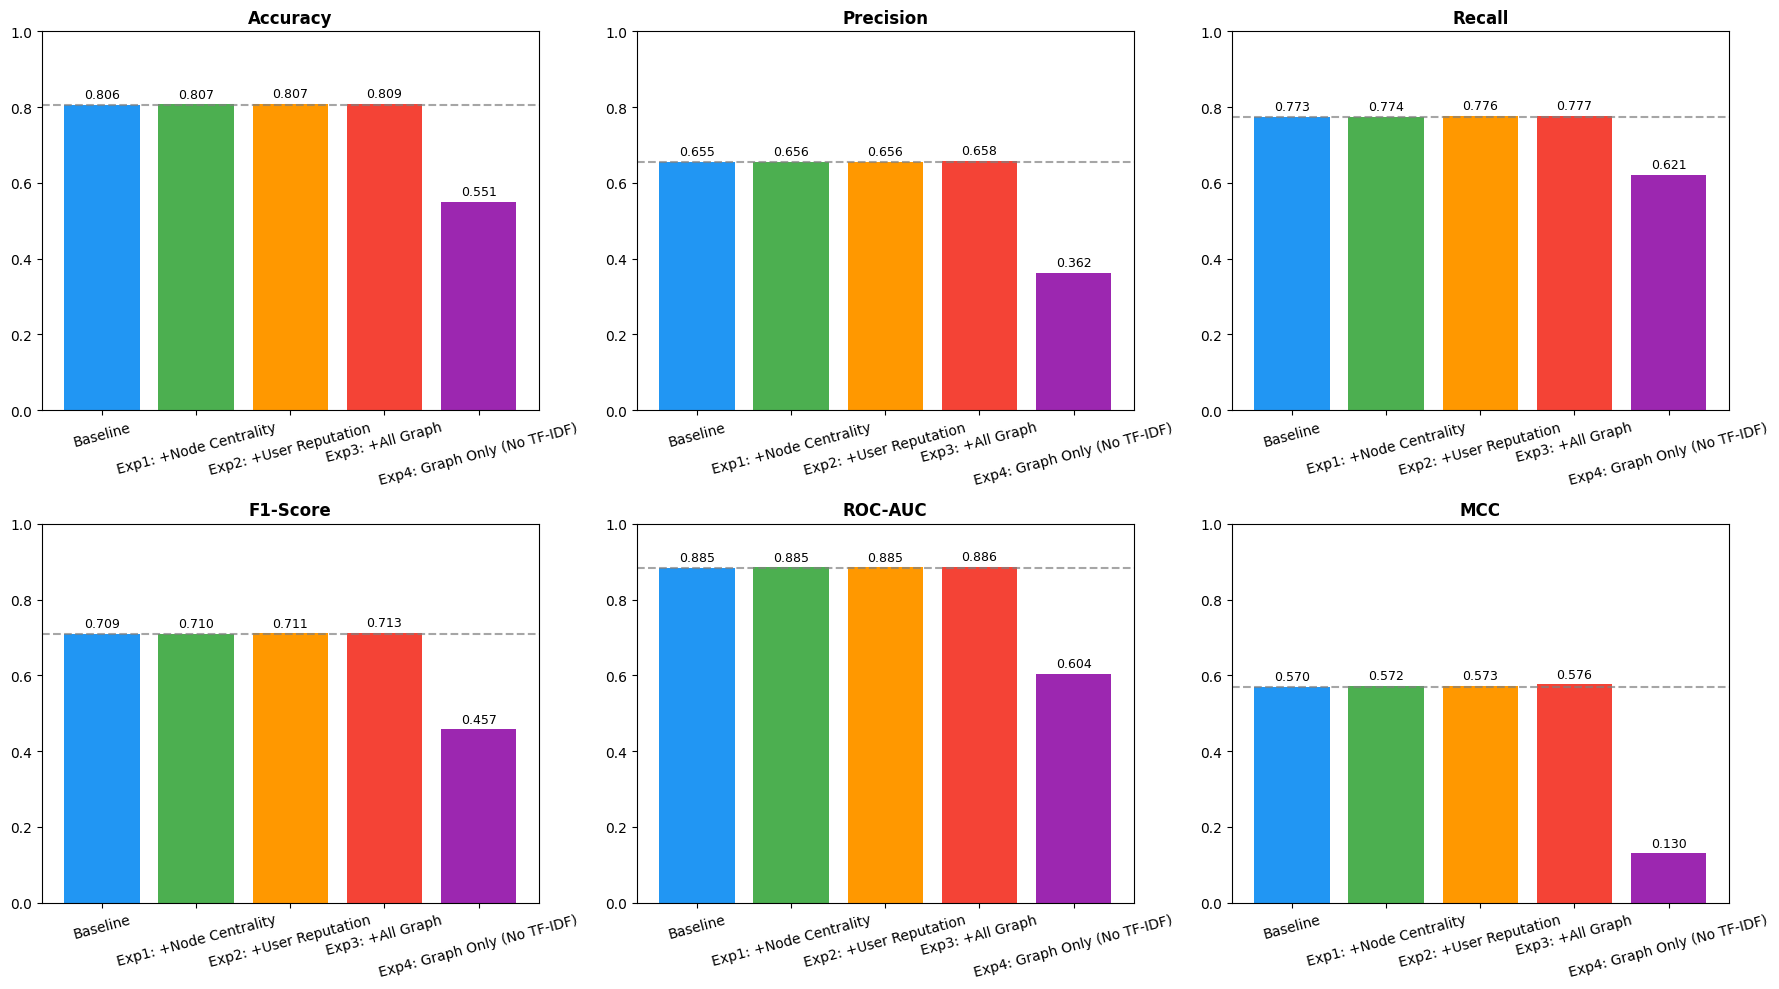

In [20]:
# Visualize results comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    values = results_df.loc[metric].values
    bars = ax.bar(results_df.columns, values, color=['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0'])
    
    # Add baseline reference line
    ax.axhline(y=baseline_metrics[metric], color='gray', linestyle='--', alpha=0.7, label='Baseline')
    
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Confusion Matrix Comparison

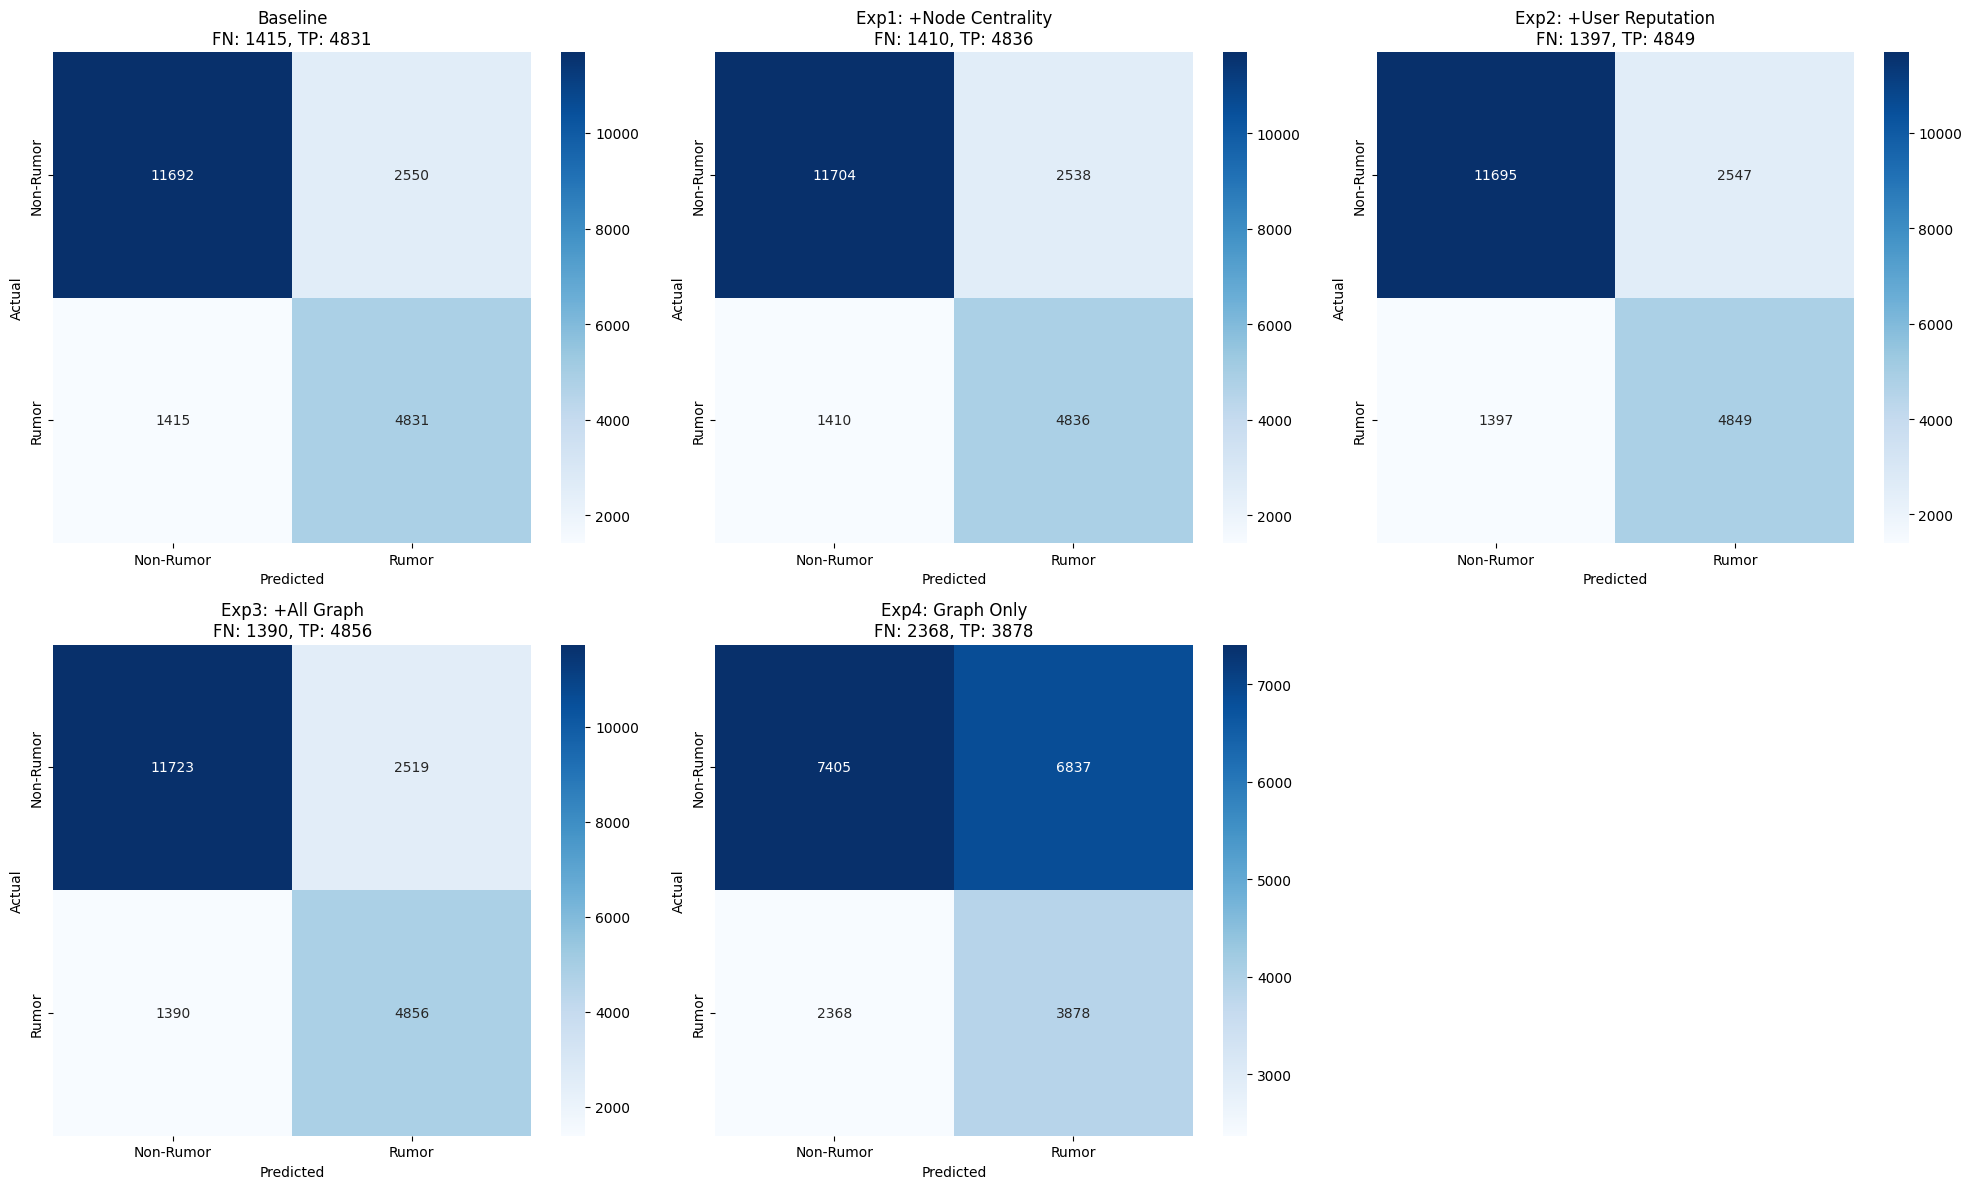

In [21]:
# Compare confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

confusion_matrices = {
    'Baseline': confusion_matrix(y_test, y_pred_baseline),
    'Exp1: +Node Centrality': confusion_matrix(y_test, y_pred_exp1),
    'Exp2: +User Reputation': confusion_matrix(y_test, y_pred_exp2),
    'Exp3: +All Graph': confusion_matrix(y_test, y_pred_exp3),
    'Exp4: Graph Only': confusion_matrix(y_test, y_pred_exp4),
}

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Rumor', 'Rumor'],
                yticklabels=['Non-Rumor', 'Rumor'],
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nFN: {cm[1,0]}, TP: {cm[1,1]}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

# Hide empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

## 10. False Negative Analysis

In [22]:
# Analyze false negative reduction
fn_baseline = confusion_matrix(y_test, y_pred_baseline)[1, 0]
fn_exp3 = confusion_matrix(y_test, y_pred_exp3)[1, 0]

fn_reduction = fn_baseline - fn_exp3
fn_reduction_pct = (fn_reduction / fn_baseline) * 100

print("=" * 60)
print("FALSE NEGATIVE ANALYSIS")
print("=" * 60)
print(f"Baseline False Negatives: {fn_baseline}")
print(f"Best Model False Negatives: {fn_exp3}")
print(f"Reduction: {fn_reduction} ({fn_reduction_pct:.1f}%)")
print("=" * 60)

# Identify rumors that were correctly classified with graph features
# but were missed by baseline
test_indices = X_test_idx
rumor_mask = y_test == 1

# FN in baseline but TP in exp3
baseline_fn_mask = (y_pred_baseline == 0) & rumor_mask
exp3_tp_mask = (y_pred_exp3 == 1) & rumor_mask
recovered_mask = baseline_fn_mask & exp3_tp_mask

recovered_indices = test_indices[recovered_mask]
print(f"\nRumors recovered by graph features: {len(recovered_indices)}")

# Analyze characteristics of recovered rumors
if len(recovered_indices) > 0:
    recovered_df = df_enriched.iloc[recovered_indices]
    print("\nRecovered Rumor Characteristics:")
    print("=" * 60)
    display(recovered_df[get_graph_feature_columns()].describe().round(3))

FALSE NEGATIVE ANALYSIS
Baseline False Negatives: 1415
Best Model False Negatives: 1390
Reduction: 25 (1.8%)

Rumors recovered by graph features: 131

Recovered Rumor Characteristics:


,node_in_degree,node_out_degree,pagerank_score,betweenness_centrality,closeness_centrality,user_prior_rumor_ratio,user_post_count,user_thread_count,user_avg_depth,subtree_reply_count,sibling_count,position_in_thread,source_user_credibility,source_network_size
count,131.0,131.0,131.0,131.0,131.0,131.000,131.000,131.000,131.000,131.0,131.0,131.000,131.000,131.000
mean,0.0,0.0,0.0,0.0,0.0,0.085,50.763,4.145,1.872,0.0,0.0,49.901,0.936,42.931
std,0.0,0.0,0.0,0.0,0.0,0.203,28.800,12.195,1.337,0.0,0.0,52.088,0.176,28.597
min,0.0,0.0,0.0,0.0,0.0,0.000,1.000,1.000,0.000,0.0,0.0,1.000,0.000,1.000
25%,0.0,0.0,0.0,0.0,0.0,0.000,32.000,2.000,1.349,0.0,0.0,12.000,0.952,19.000
50%,0.0,0.0,0.0,0.0,0.0,0.000,63.000,2.000,1.688,0.0,0.0,31.000,1.000,37.000
75%,0.0,0.0,0.0,0.0,0.0,0.048,80.000,3.000,1.760,0.0,0.0,62.000,1.000,63.000
max,0.0,0.0,0.0,0.0,0.0,1.000,108.000,104.000,8.000,0.0,0.0,222.000,1.000,108.000


In [23]:
# Analyze remaining false negatives
remaining_fn_mask = (y_pred_exp3 == 0) & rumor_mask
remaining_fn_indices = test_indices[remaining_fn_mask]

print(f"\nRemaining False Negatives (still missed): {len(remaining_fn_indices)}")

if len(remaining_fn_indices) > 0:
    remaining_fn_df = df_enriched.iloc[remaining_fn_indices]
    print("\nRemaining FN Characteristics:")
    print("=" * 60)
    display(remaining_fn_df[get_graph_feature_columns()].describe().round(3))
    
    # Compare with recovered rumors
    if len(recovered_indices) > 0:
        print("\nComparison: Recovered vs Remaining FN")
        print("=" * 60)
        comparison = pd.DataFrame({
            'Recovered Rumors': recovered_df[get_graph_feature_columns()].mean(),
            'Remaining FN': remaining_fn_df[get_graph_feature_columns()].mean(),
        })
        comparison['Difference'] = comparison['Recovered Rumors'] - comparison['Remaining FN']
        display(comparison.round(3))


Remaining False Negatives (still missed): 1390

Remaining FN Characteristics:


,node_in_degree,node_out_degree,pagerank_score,betweenness_centrality,closeness_centrality,user_prior_rumor_ratio,user_post_count,user_thread_count,user_avg_depth,subtree_reply_count,sibling_count,position_in_thread,source_user_credibility,source_network_size
count,1390.0,1390.0,1390.0,1390.0,1390.0,1390.000,1390.00,1390.000,1390.000,1390.0,1390.0,1390.000,1390.000,1390.000
mean,0.0,0.0,0.0,0.0,0.0,0.071,19.49,2.791,1.290,0.0,0.0,78.205,0.920,23.127
std,0.0,0.0,0.0,0.0,0.0,0.184,21.03,4.210,1.005,0.0,0.0,75.532,0.196,23.767
min,0.0,0.0,0.0,0.0,0.0,0.000,1.00,1.000,0.000,0.0,0.0,1.000,0.000,1.000
25%,0.0,0.0,0.0,0.0,0.0,0.000,4.00,1.000,0.657,0.0,0.0,14.000,0.952,4.000
50%,0.0,0.0,0.0,0.0,0.0,0.000,12.00,2.000,1.000,0.0,0.0,43.000,1.000,15.000
75%,0.0,0.0,0.0,0.0,0.0,0.048,30.00,3.000,1.688,0.0,0.0,137.000,1.000,33.000
max,0.0,0.0,0.0,0.0,0.0,1.000,108.00,104.000,8.000,0.0,0.0,287.000,1.000,108.000



Comparison: Recovered vs Remaining FN


,Recovered Rumors,Remaining FN,Difference
node_in_degree,0.000,0.000,0.000
node_out_degree,0.000,0.000,0.000
pagerank_score,0.000,0.000,0.000
betweenness_centrality,0.000,0.000,0.000
closeness_centrality,0.000,0.000,0.000
user_prior_rumor_ratio,0.085,0.071,0.014
user_post_count,50.763,19.490,31.273
user_thread_count,4.145,2.791,1.354
user_avg_depth,1.872,1.290,0.582
subtree_reply_count,0.000,0.000,0.000


## 11. Feature Importance Analysis

GRAPH FEATURE IMPORTANCE (Logistic Regression Coefficients)


,feature,coefficient,abs_coefficient
11,position_in_thread,-0.1951,0.1951
6,user_post_count,0.1429,0.1429
13,source_network_size,0.1043,0.1043
8,user_avg_depth,0.0420,0.0420
5,user_prior_rumor_ratio,0.0405,0.0405
7,user_thread_count,-0.0221,0.0221
12,source_user_credibility,0.0082,0.0082
4,closeness_centrality,0.0000,0.0000
2,pagerank_score,0.0000,0.0000
1,node_out_degree,0.0000,0.0000


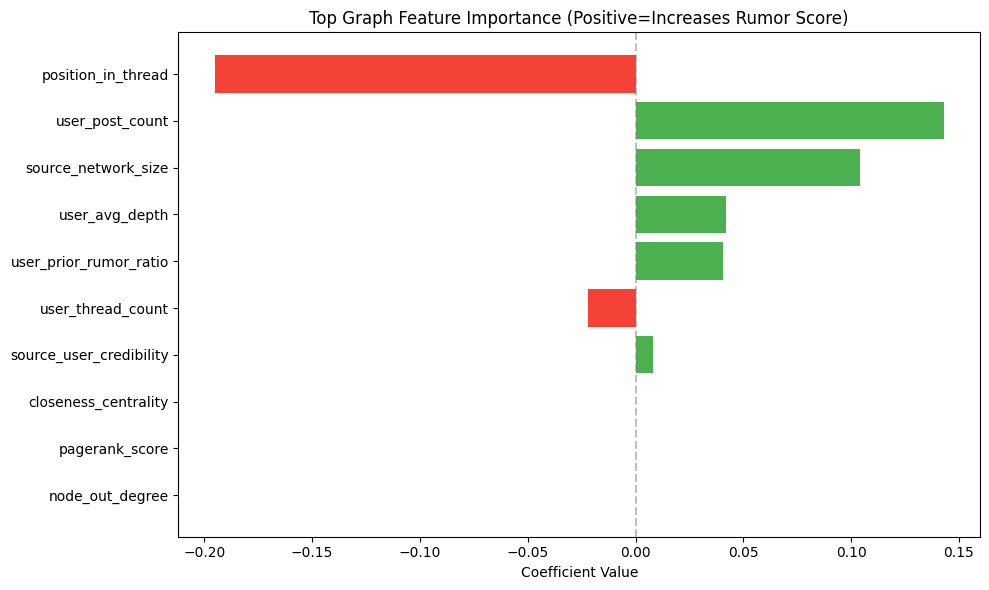

In [24]:
# Analyze feature importance from the best model (Exp3)
# For Logistic Regression, coefficients indicate feature importance

# Get coefficients for graph features (they come after TF-IDF and propagation)
n_tfidf = X_train_baseline.shape[1]
graph_coefficients = model_exp3.coef_[0, n_tfidf:]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': all_graph_cols,
    'coefficient': graph_coefficients[:len(all_graph_cols)],
    'abs_coefficient': np.abs(graph_coefficients[:len(all_graph_cols)])
})

feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

print("=" * 60)
print("GRAPH FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("=" * 60)
display(feature_importance.round(4))

# Visualize top features
plt.figure(figsize=(10, 6))
top_n = min(10, len(feature_importance))
top_features = feature_importance.head(top_n)

colors = ['#4CAF50' if c > 0 else '#F44336' for c in top_features['coefficient']]
plt.barh(range(top_n), top_features['coefficient'], color=colors)
plt.yticks(range(top_n), top_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Top Graph Feature Importance (Positive=Increases Rumor Score)')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 12. Summary and Conclusions

In [25]:
# Find best model for recall
recall_scores = {
    'Baseline': baseline_metrics['Recall'],
    'Exp1: +Node Centrality': exp1_metrics['Recall'],
    'Exp2: +User Reputation': exp2_metrics['Recall'],
    'Exp3: +All Graph': exp3_metrics['Recall'],
    'Exp4: Graph Only': exp4_metrics['Recall'],
}

best_model = max(recall_scores, key=recall_scores.get)
best_recall = recall_scores[best_model]

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Best model for Recall: {best_model}")
print(f"Best Recall: {best_recall:.4f}")
print(f"Baseline Recall: {baseline_metrics['Recall']:.4f}")
print(f"Recall Improvement: {(best_recall - baseline_metrics['Recall']):.4f} ({((best_recall - baseline_metrics['Recall']) / baseline_metrics['Recall'] * 100):.1f}%)")
print("=" * 60)

print("\nKey Findings:")
print("-" * 60)
print(f"1. Graph features {'improved' if best_recall > baseline_metrics['Recall'] else 'did not improve'} recall")
print(f"2. Best feature set: {best_model}")
print(f"3. False negatives reduced by: {fn_reduction} ({fn_reduction_pct:.1f}%)")
print(f"4. Most important graph feature: {feature_importance.iloc[0]['feature']}")
print("=" * 60)

SUMMARY
Best model for Recall: Exp3: +All Graph
Best Recall: 0.7775
Baseline Recall: 0.7735
Recall Improvement: 0.0040 (0.5%)

Key Findings:
------------------------------------------------------------
1. Graph features improved recall
2. Best feature set: Exp3: +All Graph
3. False negatives reduced by: 25 (1.8%)
4. Most important graph feature: position_in_thread


## 13. Save Results

In [26]:
# Save experiment results for future reference
import json
import os

# Create results directory
results_dir = '../project_brain_bundle/regression_pack'
os.makedirs(results_dir, exist_ok=True)

# Save metrics
experiment_results = {
    'baseline': {k: float(v) for k, v in baseline_metrics.items()},
    'exp1_node_centrality': {k: float(v) for k, v in exp1_metrics.items()},
    'exp2_user_reputation': {k: float(v) for k, v in exp2_metrics.items()},
    'exp3_all_graph': {k: float(v) for k, v in exp3_metrics.items()},
    'exp4_graph_only': {k: float(v) for k, v in exp4_metrics.items()},
}

with open(os.path.join(results_dir, 'graph_feature_experiments.json'), 'w') as f:
    json.dump(experiment_results, f, indent=2)

print(f"Results saved to {os.path.join(results_dir, 'graph_feature_experiments.json')}")

# Save enriched features for future use
print(f"\nEnriched dataset shape: {df_enriched.shape}")
print("Note: Enriched features are available in memory as 'df_enriched'")
print("Do NOT save to data/processed/ to maintain frozen state")

Results saved to ../project_brain_bundle/regression_pack\graph_feature_experiments.json

Enriched dataset shape: (1434577, 31)
Note: Enriched features are available in memory as 'df_enriched'
Do NOT save to data/processed/ to maintain frozen state
